In [1]:
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt

Headlights: 2 gaussian blobs same covariance with some overlap, 1 class each

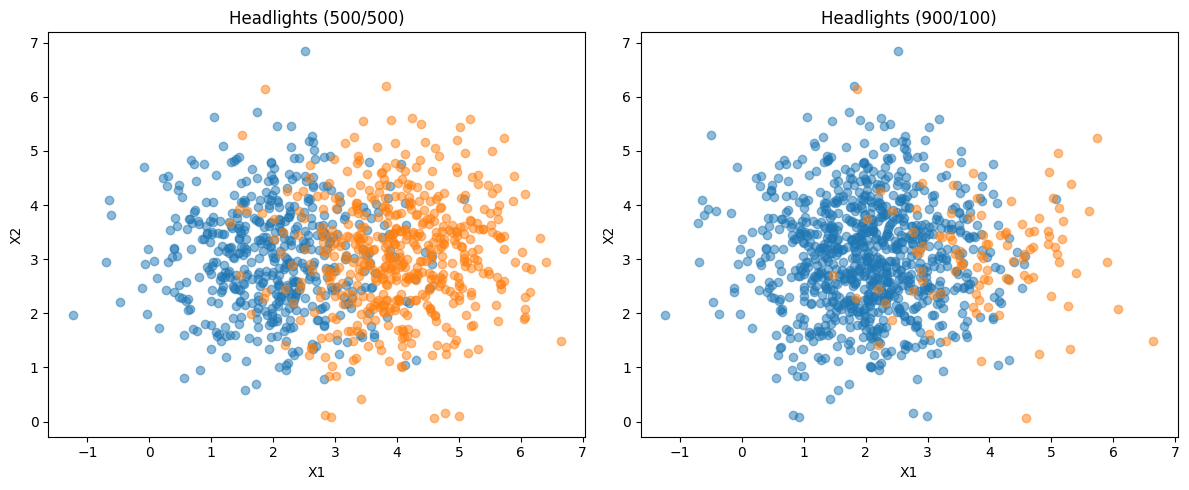

In [2]:
def headlights(n_sample, show):
    X_headlights, y_headlights=make_blobs(n_samples=n_sample, centers=[[2,3],[4,3]],cluster_std=1.0, random_state=42)
    if show=='show' :
        a,b = n_sample[0],n_sample[1]
        plt.scatter(X_headlights[y_headlights == 0, 0], X_headlights[y_headlights == 0, 1], alpha=0.5, label='Classe 0 (50%)')
        plt.scatter(X_headlights[y_headlights == 1, 0], X_headlights[y_headlights == 1, 1], alpha=0.5, label='Classe 1 (50%)')
        plt.title(f'Headlights ({a}/{b})')
        plt.xlabel('X1')
        plt.ylabel('X2')
        plt.show()
    if show=='ex' :
        a,b = n_sample[0],n_sample[1]
        plt.scatter(X_headlights[y_headlights == 0, 0], X_headlights[y_headlights == 0, 1], alpha=0.5, label='Classe 0 (50%)')
        plt.scatter(X_headlights[y_headlights == 1, 0], X_headlights[y_headlights == 1, 1], alpha=0.5, label='Classe 1 (50%)')
        plt.title(f'Headlights ({a}/{b})')
        plt.xlabel('X1')
        plt.ylabel('X2')
    return (X_headlights, y_headlights)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
#balanced
X_headlights_balanced, y_headlights_balanced= headlights([500,500], "ex")

plt.subplot(1, 2, 2)
#unbalanced
X_headlights_unbalanced, y_headlights_unbalanced= headlights([900,100], "ex")

plt.tight_layout()
plt.show()


Shell: 1 circular gaussian blob (class A) and one somewhat rectangular thin strip of points with the
width of the blob (class B) slightly overlapping the edge of the blob. Balanced classes.


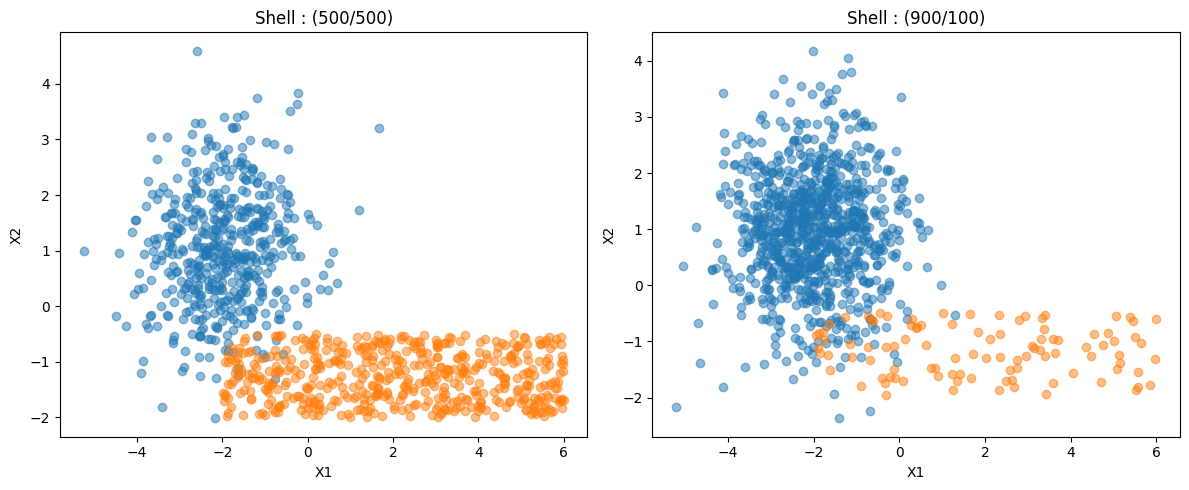

In [3]:
def Shell(n_sample, show):

    bal1 = n_sample[0]
    bal2 = n_sample[1]
    class_a = np.random.multivariate_normal([-2, 1],[[1, 0], [0, 1]],  bal1)
    y_a = np.zeros(bal1)

    # 2. CLASSE B
    x_rect = np.random.uniform(-2, 6, bal2) 
    y_rect = np.random.uniform(-2, -0.5, bal2)
    class_b = np.column_stack((x_rect, y_rect))

    y_b=np.ones(bal2)
    X_shell, y_shell = np.vstack([class_a,class_b]), np.hstack([y_a,y_b])

    if show == "show":
        plt.scatter(X_shell[y_shell == 0, 0], X_shell[y_shell == 0, 1], alpha=0.5, label='Classe 0')
        plt.scatter(X_shell[y_shell == 1, 0], X_shell[y_shell == 1, 1], alpha=0.5, label='Classe 1')
        plt.title(f'Shell : ({bal1}/{bal2})')
        plt.xlabel('X1')
        plt.ylabel('X2')
        plt.show()
    if show == "ex":
        plt.scatter(X_shell[y_shell == 0, 0], X_shell[y_shell == 0, 1], alpha=0.5, label='Classe 0')
        plt.scatter(X_shell[y_shell == 1, 0], X_shell[y_shell == 1, 1], alpha=0.5, label='Classe 1')
        plt.title(f'Shell : ({bal1}/{bal2})')
        plt.xlabel('X1')
        plt.ylabel('X2')
    return (X_shell, y_shell)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
#balanced
X_shell_balanced, y_shell_balanced = Shell([500,500], "ex")

plt.subplot(1, 2, 2)
#unbalanced
X_shell_unbalanced, y_shell_unbalanced = Shell([900,100], "ex")


plt.tight_layout()
plt.show()

DD: 1 half circular blob, D shaped (class A) and another similar one to the right almost touching but
with almost no or minimal overlaping (class B)

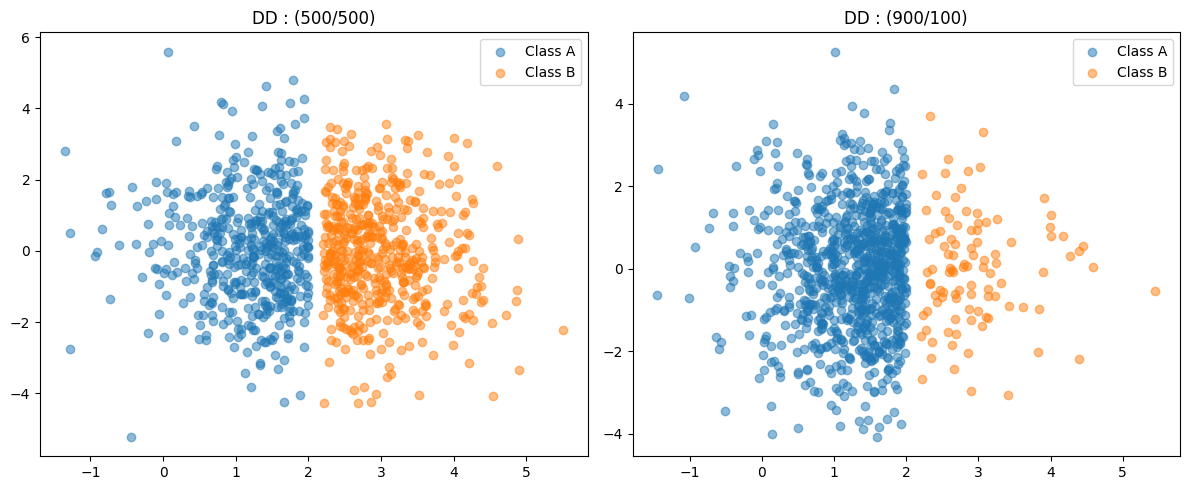

In [4]:
def generate_d_shape(n_samples, center_x=0, center_y=0, direction='left'):
    d_points = np.empty((0, 2))  # Initialise un tableau vide à 2 colonnes
    
    while len(d_points) < n_samples:
        needed = n_samples - len(d_points)
        batch_size = int(needed * 2) 
        
        points = np.random.normal(loc=[center_x, center_y], 
                                  scale=[1.0, 1.5], 
                                  size=(batch_size, 2))
        
        if direction == 'left':
            filtered = points[points[:, 0] <= center_x]
        else:
            filtered = points[points[:, 0] >= center_x]
        
        d_points = np.vstack([d_points, filtered])

    return d_points[:n_samples]


def DD(n_sample, show):
    bal1,bal2 = n_sample[0], n_sample[1]
    class_a_bal = generate_d_shape(bal1, center_x=2, direction='left')
    class_b_bal = generate_d_shape(bal2, center_x=2.2, direction='right')
    X_DD = np.vstack([class_a_bal, class_b_bal])
    y_DD = np.hstack([np.zeros(bal1), np.ones(bal2)])
    if show=="ex" :
        plt.scatter(X_DD[y_DD==0, 0], X_DD[y_DD==0, 1], alpha=0.5, label='Class A')
        plt.scatter(X_DD[y_DD==1, 0], X_DD[y_DD==1, 1], alpha=0.5, label='Class B')
        plt.title(f'DD : ({bal1}/{bal2})')
        plt.legend()
    if show=="show":
        plt.scatter(X_DD[y_DD==0, 0], X_DD[y_DD==0, 1], alpha=0.5, label='Class A')
        plt.scatter(X_DD[y_DD==1, 0], X_DD[y_DD==1, 1], alpha=0.5, label='Class B')
        plt.title(f'DD : ({bal1}/{bal2})')
        plt.legend()
        plt.show()
    return(X_DD,y_DD)


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# balanced
X_DD_balanced, y_DD_balanced= DD([500,500], "ex")

plt.subplot(1, 2, 2)
# Unbalanced
X_DD_unbalanced, y_DD_unbalanced= DD([900,100], "ex")

plt.tight_layout()
plt.show()

Xor

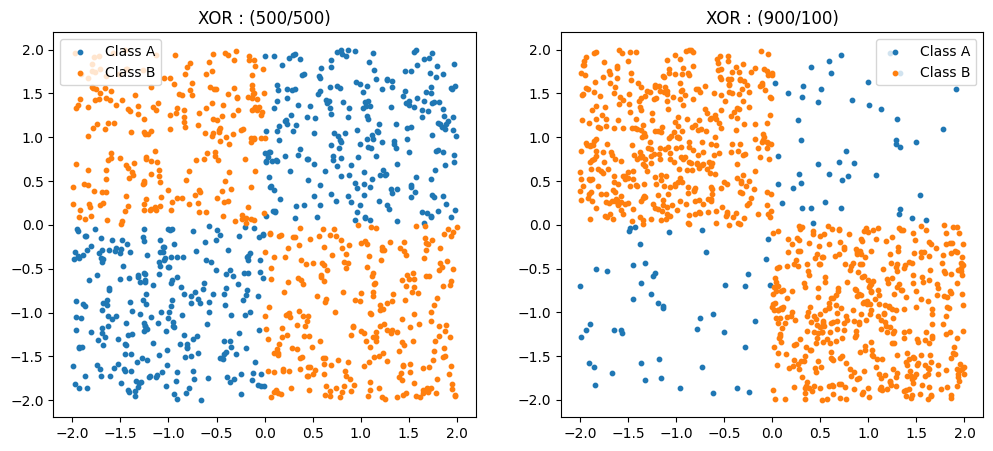

In [13]:
def Xor(n_sample, show):
    bal1, bal2=n_sample[0], n_sample[1]
    n_samples = bal1 + bal2
    p_balanced = bal2/n_samples

    n_class_b = int(n_samples * (1 - p_balanced))
    n_class_a = n_samples - n_class_b
    
    X = np.random.uniform(-2, 2, (n_samples * 10, 2))

    labels = (X[:, 0] > 0) ^ (X[:, 1] > 0)
    
    X_a = X[labels == 0]
    X_b = X[labels == 1]
    
    X_xor = np.vstack([X_a[:n_class_a], X_b[:n_class_b]])
    y_xor = np.hstack([np.zeros(n_class_a), np.ones(n_class_b)])

    if show == "ex" :
        plt.scatter(X_xor[y_xor==0, 0], X_xor[y_xor==0, 1], s=10, label='Class A')
        plt.scatter(X_xor[y_xor==1, 0], X_xor[y_xor==1, 1], s=10, label='Class B')
        plt.title(f"XOR : ({bal1}/{bal2})")
        plt.legend()

    if show == "show" :
        plt.scatter(X_xor[y_xor==0, 0], X_xor[y_xor==0, 1], s=10, label='Class A')
        plt.scatter(X_xor[y_xor==1, 0], X_xor[y_xor==1, 1], s=10, label='Class B')
        plt.title(f"XOR : ({bal1}/{bal2})")
        plt.legend()
        plt.show()
    return X_xor, y_xor

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# Balanced
X_xor_balanced, y_xor_balanced = Xor([500,500], "ex")

plt.subplot(1, 2, 2)
# Unbalanced
X_xor_unbalanced, y_xor_unbalanced = Xor([900,100], "ex")

plt.show()

Chess4

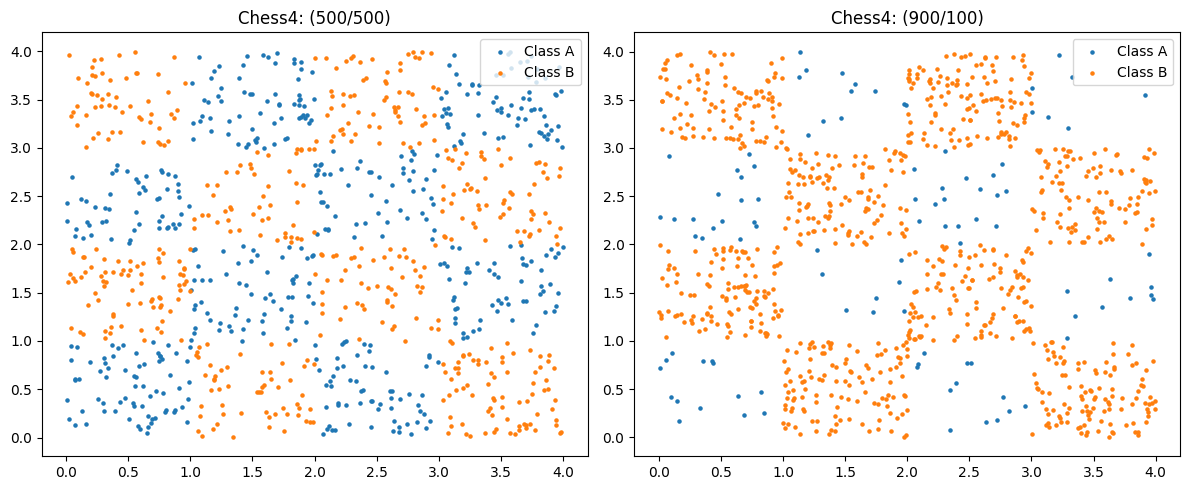

In [ ]:
def Chess4(n_sample, show):
    bal1, bal2=n_sample[0], n_sample[1]
    n_samples = bal1 + bal2
    p_balanced = bal2/n_samples
    n_class_b = int(n_samples * (1 - p_balanced))
    n_class_a = n_samples - n_class_b
    
    X_pool = np.random.uniform(0, 4, (n_samples * 10, 2))

    logic = (np.floor(X_pool[:, 0]).astype(int) + np.floor(X_pool[:, 1]).astype(int)) % 2
    
    X_a = X_pool[logic == 0]
    X_b = X_pool[logic == 1]
    
    X_chess4 = np.vstack([X_a[:n_class_a], X_b[:n_class_b]])
    y_chess4 = np.hstack([np.zeros(n_class_a), np.ones(n_class_b)])

    if show=="ex":
        plt.scatter(X_chess4[y_chess4==0, 0], X_chess4[y_chess4==0, 1], s=5, label='Class A')
        plt.scatter(X_chess4[y_chess4==1, 0], X_chess4[y_chess4==1, 1], s=5, label='Class B')
        plt.title(f"Chess4: ({bal1}/{bal2})")
        plt.legend()
    if show=="show":
        plt.scatter(X_chess4[y_chess4==0, 0], X_chess4[y_chess4==0, 1], s=5, label='Class A')
        plt.scatter(X_chess4[y_chess4==1, 0], X_chess4[y_chess4==1, 1], s=5, label='Class B')
        plt.title(f"Chess4: ({bal1}/{bal2})")
        plt.legend()
        plt.show()
    return X_chess4, y_chess4

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# Balanced
X_chess4_balanced, y_chess4_balanced = Chess4([500,500], "ex")

plt.subplot(1, 2, 2)
# Unbalanced
X_chess4_unbalanced, y_chess4_unbalanced = Chess4([900,100], "ex")

plt.tight_layout()
plt.show()

Roseta2: 1 round central blob (class A), 1 ring around the central blob, like a blob without the central
part, where class A is (class B)


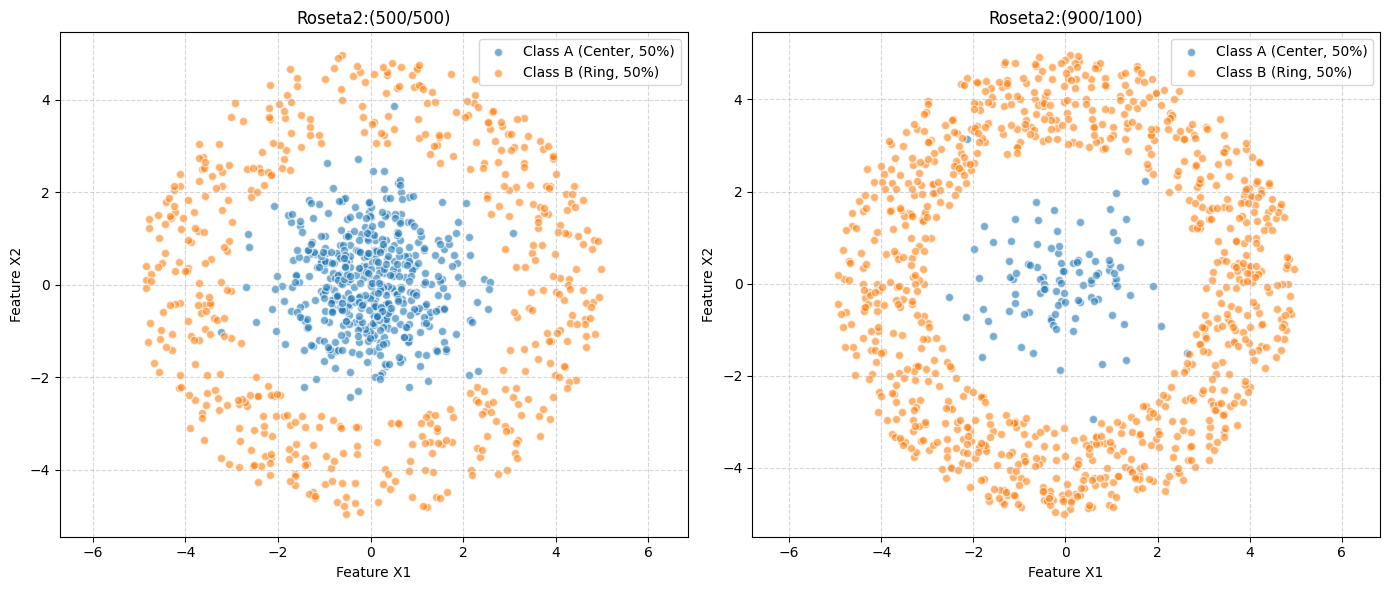

In [26]:
def Roseta2(n_sample, show):
    bal1, bal2=n_sample[0], n_sample[1]
    n_samples = bal1 + bal2
    p_balanced = bal2/n_samples

    n_samples_b = int(n_samples * (1 - p_balanced))
    n_samples_a = n_samples - n_samples_b
    
    center = [0, 0]

    cluster_std = 1.0
    X_a = np.random.normal(loc=center, scale=cluster_std, size=(n_samples_a, 2))
    
    r_min = 3.0
    r_max = 5.0
    
    theta = np.random.uniform(0, 2 * np.pi, n_samples_b)
    
    r = np.sqrt(np.random.uniform(r_min**2, r_max**2, n_samples_b))
    
    x_ring = center[0] + r * np.cos(theta)
    y_ring = center[1] + r * np.sin(theta)
    X_b = np.column_stack((x_ring, y_ring))

    X_roseta2 = np.vstack([X_a, X_b])
    y_roseta2 = np.hstack([np.zeros(n_samples_a), np.ones(n_samples_b)])
    
    if show == "ex" :
        plt.scatter(X_roseta2[y_roseta2 == 0, 0],  X_roseta2[y_roseta2== 0, 1], 
            alpha=0.6, label='Class A (Center, 50%)', edgecolors='w')
        plt.scatter(X_roseta2[y_roseta2 == 1, 0], 
                    X_roseta2[y_roseta2 == 1, 1], 
                    alpha=0.6, label='Class B (Ring, 50%)', edgecolors='w')

        plt.title(f'Roseta2:({bal1}/{bal2})')
        plt.xlabel('Feature X1')
        plt.ylabel('Feature X2')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.axis('equal')

    if show == "show" :
        plt.scatter(X_roseta2[y_roseta2 == 0, 0],  X_roseta2[y_roseta2== 0, 1], 
            alpha=0.6, label='Class A (Center, 50%)', edgecolors='w')
        plt.scatter(X_roseta2[y_roseta2 == 1, 0], 
                    X_roseta2[y_roseta2 == 1, 1], 
                    alpha=0.6, label='Class B (Ring, 50%)', edgecolors='w')

        plt.title(f'Roseta2:({bal1}/{bal2})')
        plt.xlabel('Feature X1')
        plt.ylabel('Feature X2')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.axis('equal')
        plt.show()

    return X_roseta2, y_roseta2

np.random.seed(42)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
# Balanced
X_roseta_balanced, y_roseta_balanced = Roseta2([500,500], "ex")



plt.subplot(1, 2, 2)
# Unbalanced
X_roseta_unbalanced, y_roseta_unbalanced = Roseta2([900,100], "ex")

plt.tight_layout()
plt.show()

 Roseta3: Same as above, but 3 concentric rings with 2 aalternating classes


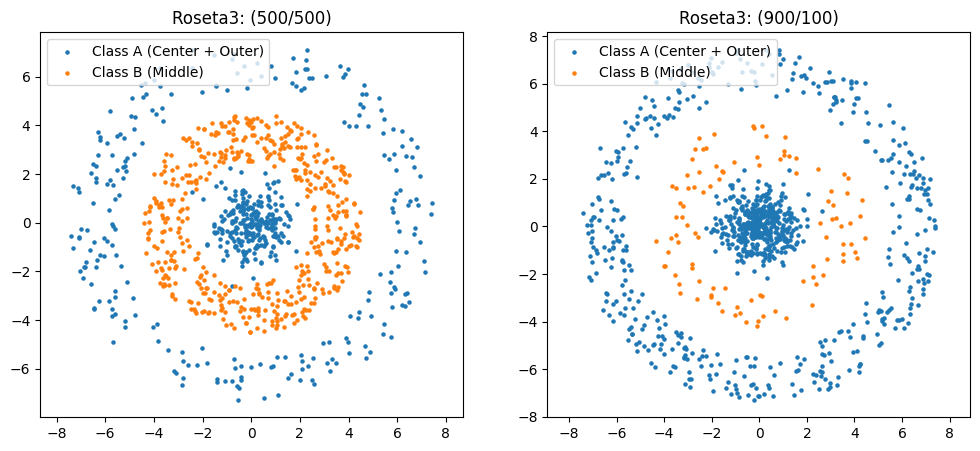

In [32]:
def Roseta3(n_sample, show):
    bal1, bal2=n_sample[0], n_sample[1]
    n_samples = bal1 + bal2
    p_balanced = bal1/n_samples

    n_samples_a = int(n_samples * p_balanced)
    n_samples_b = n_samples - n_samples_a
    
    n_a_center = n_samples_a // 2
    n_a_outer = n_samples_a - n_a_center
    
    X_a_center = np.random.normal(loc=[0, 0], scale=0.8, size=(n_a_center, 2))
    
    r_min2, r_max2 = 2.5, 4.5
    theta2 = np.random.uniform(0, 2 * np.pi, n_samples_b)
    r2 = np.sqrt(np.random.uniform(r_min2**2, r_max2**2, n_samples_b))
    X_b_middle = np.column_stack((r2 * np.cos(theta2), r2 * np.sin(theta2)))
    
    r_min3, r_max3 = 5.5, 7.5
    theta3 = np.random.uniform(0, 2 * np.pi, n_a_outer)
    r3 = np.sqrt(np.random.uniform(r_min3**2, r_max3**2, n_a_outer))
    X_a_outer = np.column_stack((r3 * np.cos(theta3), r3 * np.sin(theta3)))
    
    X_roseta3_a = np.vstack([X_a_center, X_a_outer])
    X_roseta3_b = X_b_middle
    
    X_final = np.vstack([X_roseta3_a, X_roseta3_b])
    y_final = np.hstack([np.zeros(len(X_roseta3_a)), np.ones(len(X_roseta3_b))])

    if show=="ex" :
        plt.scatter(X_final[y_final==0, 0], X_final[y_final==0, 1], s=5, label='Class A (Center + Outer)')
        plt.scatter(X_final[y_final==1, 0], X_final[y_final==1, 1], s=5, label='Class B (Middle)')
        plt.title(f"Roseta3: ({bal1}/{bal2})")
        plt.axis('equal')
        plt.legend()
    if show=="show":
        plt.scatter(X_final[y_final==0, 0], X_final[y_final==0, 1], s=5, label='Class A (Center + Outer)')
        plt.scatter(X_final[y_final==1, 0], X_final[y_final==1, 1], s=5, label='Class B (Middle)')
        plt.title(f"Roseta3: ({bal1}/{bal2})")
        plt.axis('equal')
        plt.legend()
        plt.show()
    return X_final, y_final




plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# Balanced
X_roseta3_balanced, y_roseta3_balanced = Roseta3([500,500], "ex")


plt.subplot(1, 2, 2)
# Unbalanced
X_roseta3_unbalanced, y_roseta3_unbalanced = Roseta3([900,100], "ex")

plt.show()

Test of the differents model trained on the datasets

In [33]:
X_balanced = [X_headlights_balanced, X_shell_balanced, X_DD_balanced, X_xor_balanced, X_chess4_balanced, X_roseta_balanced , X_roseta3_balanced]
X_unbalanced =[X_headlights_unbalanced, X_shell_unbalanced, X_DD_unbalanced, X_xor_unbalanced, X_chess4_unbalanced, X_roseta_unbalanced, X_roseta3_unbalanced]
y_balanced = [y_headlights_balanced, y_shell_balanced, y_DD_balanced, y_xor_balanced, y_chess4_balanced, y_roseta_balanced , y_roseta3_balanced]
y_unbalanced = [y_headlights_unbalanced, y_shell_unbalanced, y_DD_unbalanced, y_xor_unbalanced, y_chess4_unbalanced, y_roseta_unbalanced, y_roseta3_unbalanced]

In [34]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score

models = {
    "1NN": KNeighborsClassifier(n_neighbors=1),
    "5NN": KNeighborsClassifier(n_neighbors=5),
    "10NN": KNeighborsClassifier(n_neighbors=10),
    "Logistic Regression": LogisticRegression(),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis()
}
accuracy_balanced = {}
recall_balanced = {}
f1_balanced = {}
precision_balanced = {}
for name in models.keys():
    accuracy_balanced[name] = []
    recall_balanced[name] = []
    f1_balanced[name] = []
    precision_balanced[name] = []

for i in range(len(X_balanced)):

    X,y=X_balanced[i],y_balanced[i]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    for name, model in models.items():
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        accuracy_balanced[name].append(acc)
        rec = recall_score(y_test,y_pred)
        recall_balanced[name].append(rec)
        f1 = f1_score(y_test,y_pred)
        f1_balanced[name].append(f1)
        prec = precision_score(y_test,y_pred)
        precision_balanced[name].append(prec)

accuracy_unbalanced = {}
recall_unbalanced = {}
f1_unbalanced = {}
precision_unbalanced = {}
for name in models.keys():
    accuracy_unbalanced[name] = []
    recall_unbalanced[name] = []
    f1_unbalanced[name] = []
    precision_unbalanced[name] = []

for i in range(len(X_balanced)):

    X,y=X_unbalanced[i],y_unbalanced[i]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    for name, model in models.items():
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        accuracy_unbalanced[name].append(acc)
        rec = recall_score(y_test, y_pred)
        recall_unbalanced[name].append(rec)
        f1 = f1_score(y_test, y_pred)
        f1_unbalanced[name].append(f1)
        prec = precision_score(y_test,y_pred)
        precision_unbalanced[name].append(prec)


   

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833:

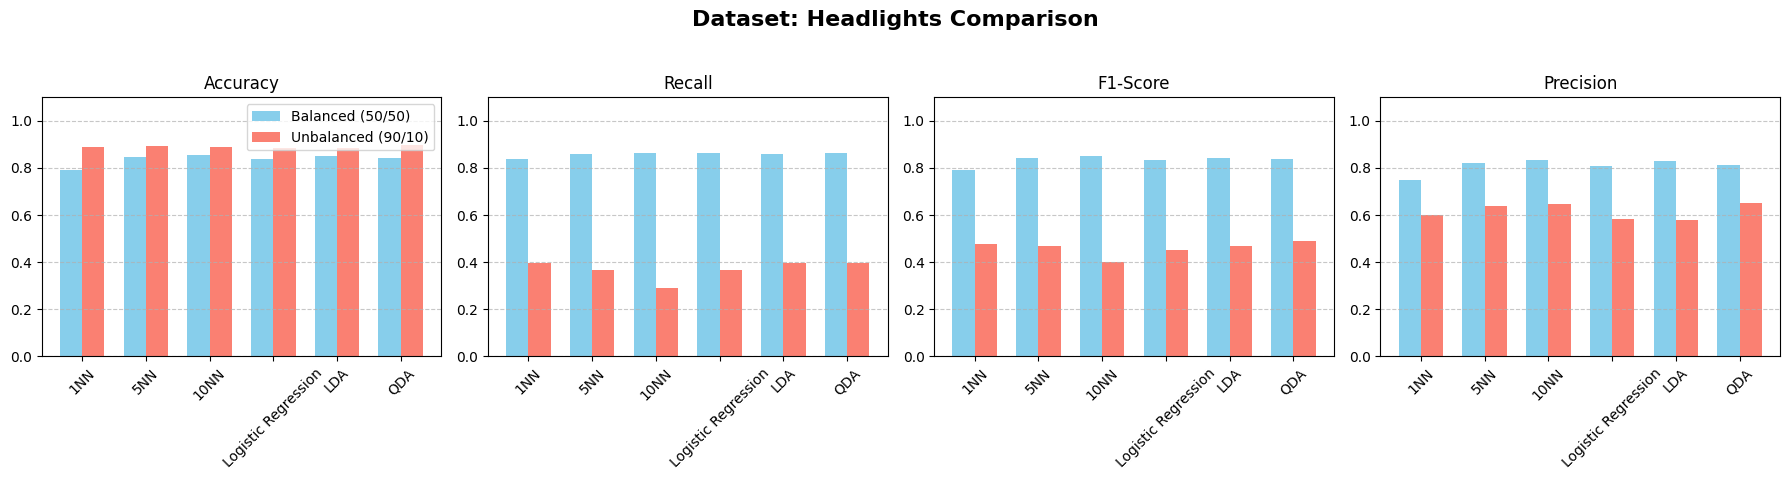

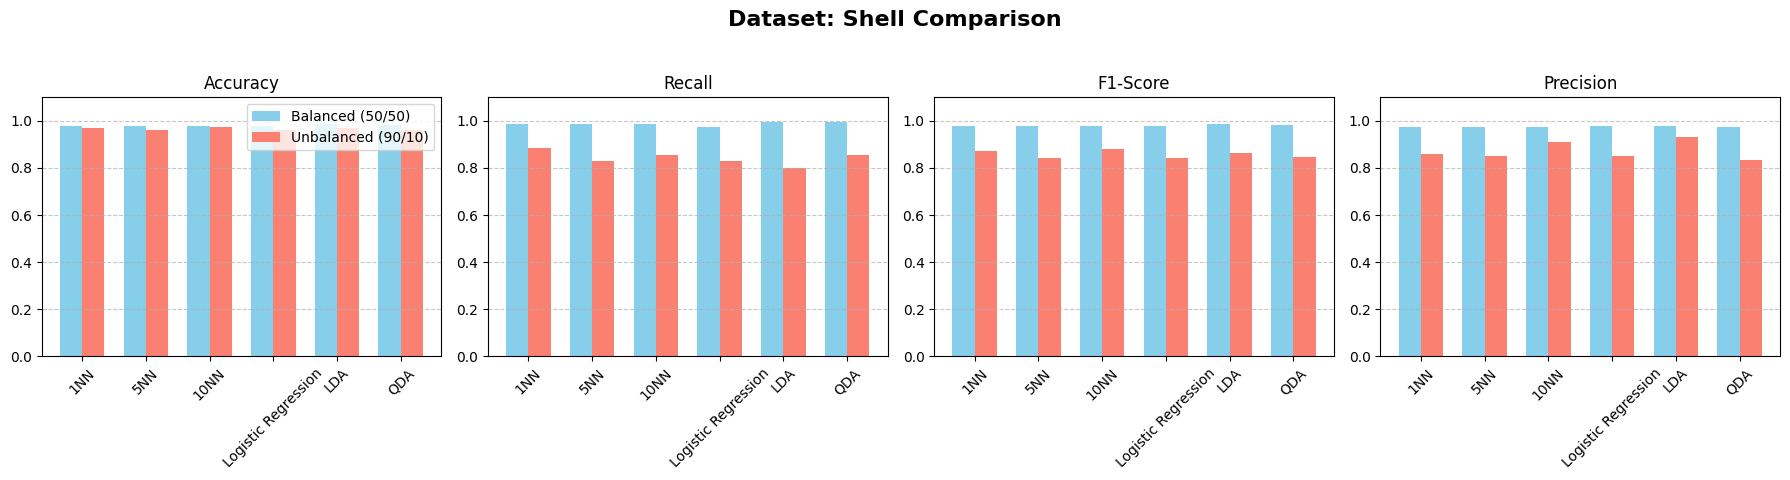

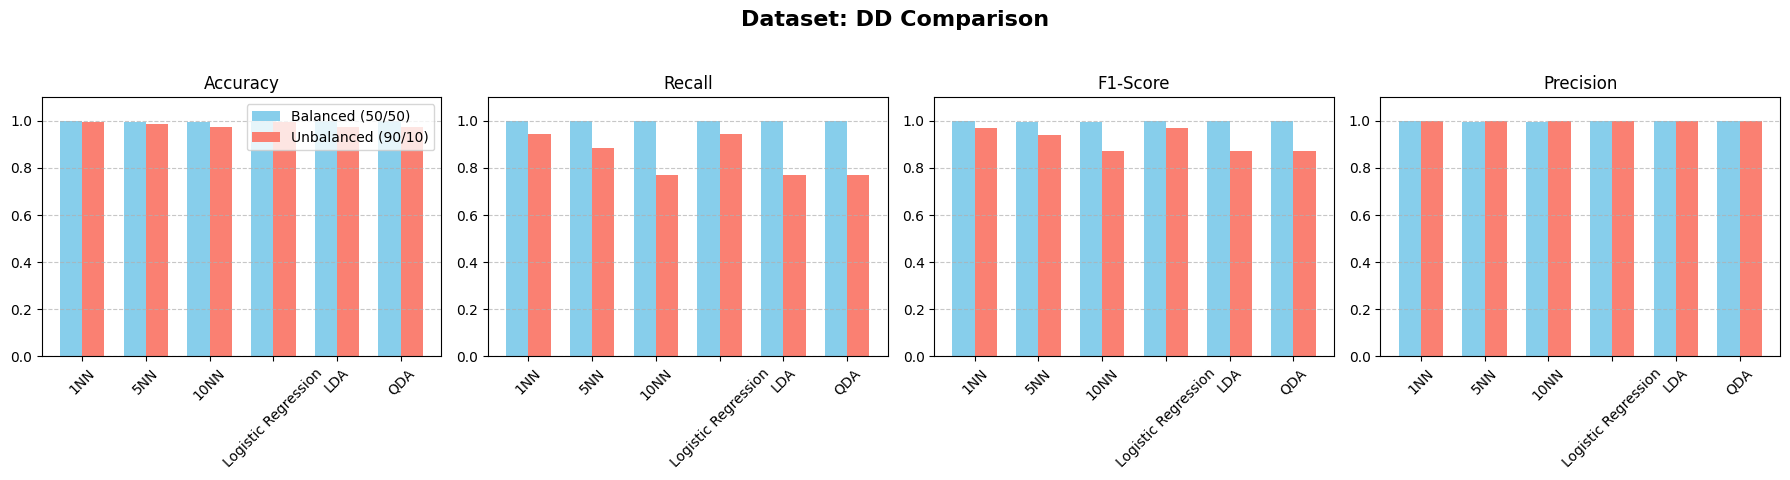

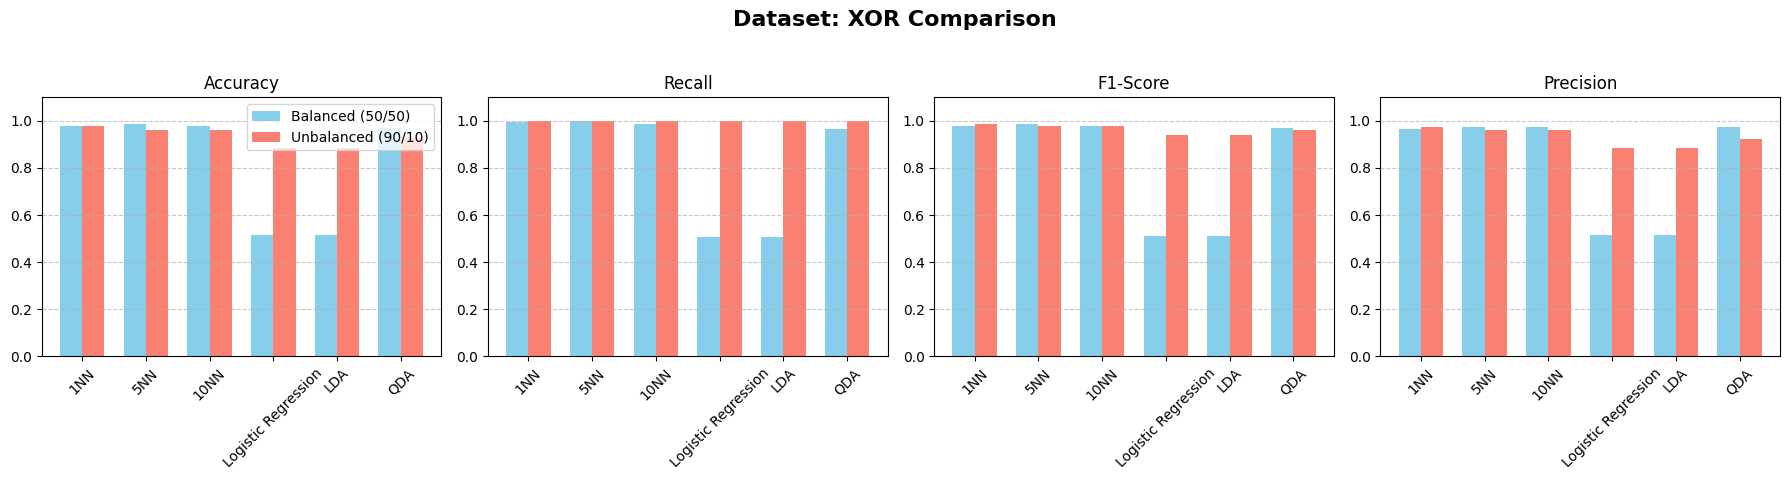

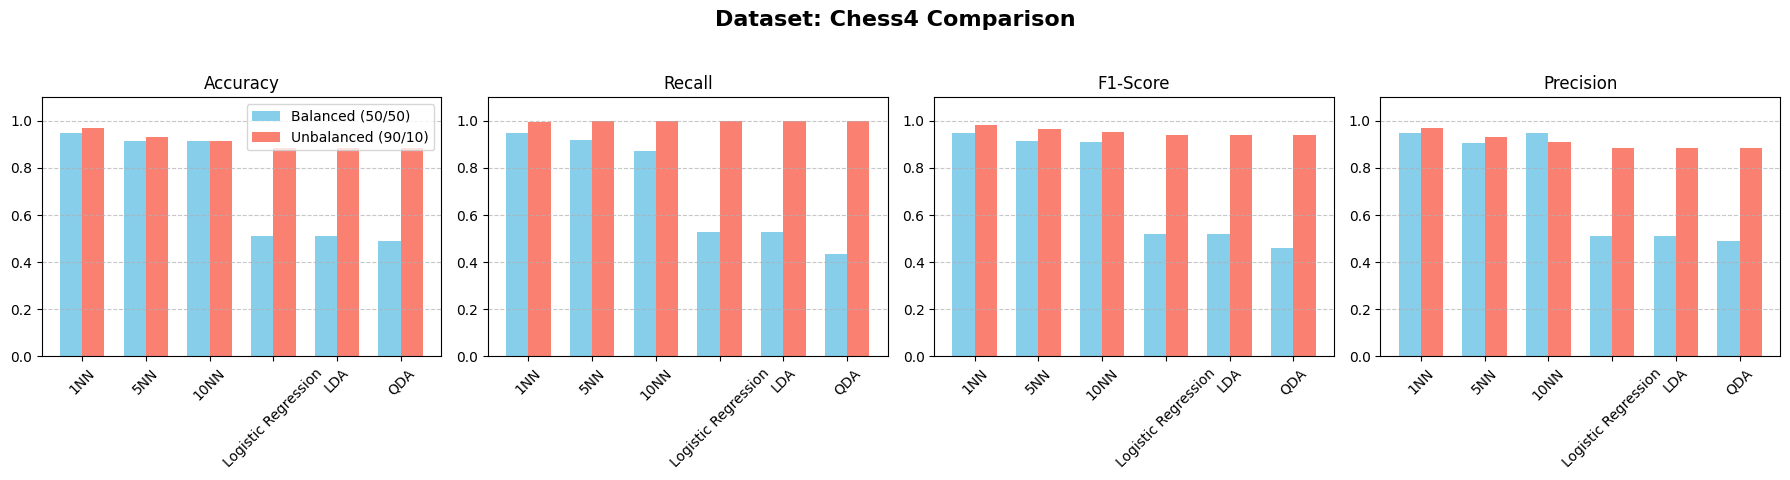

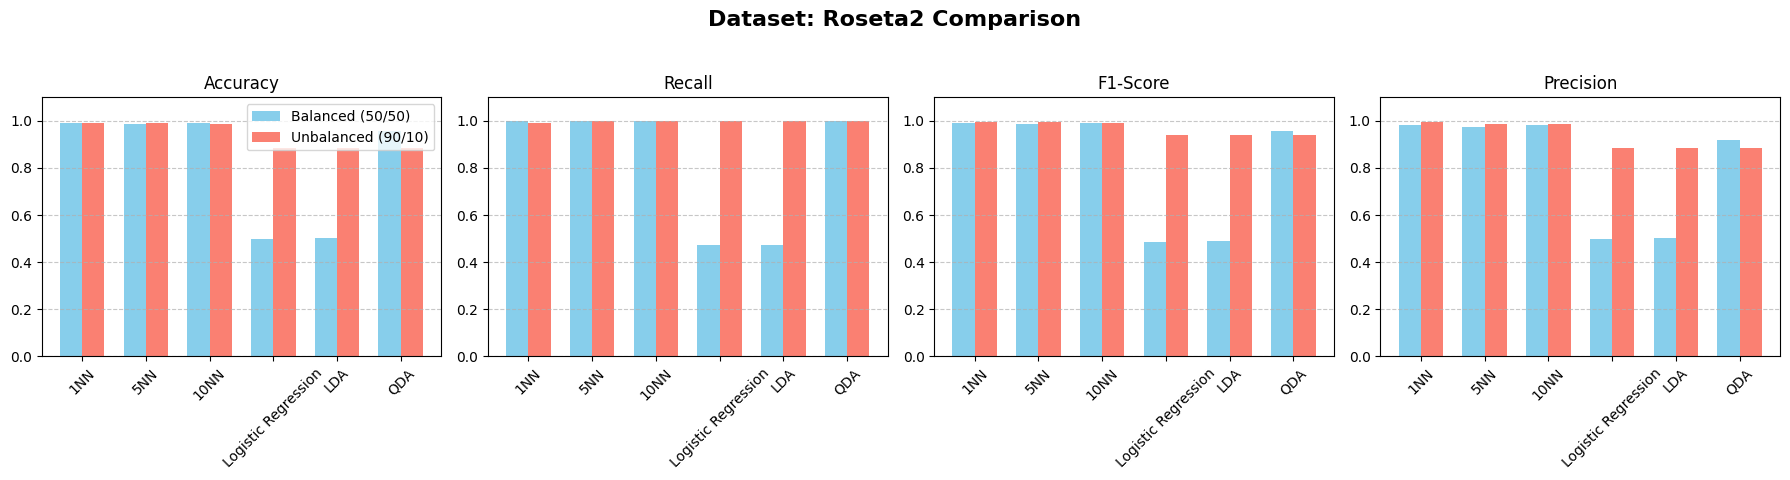

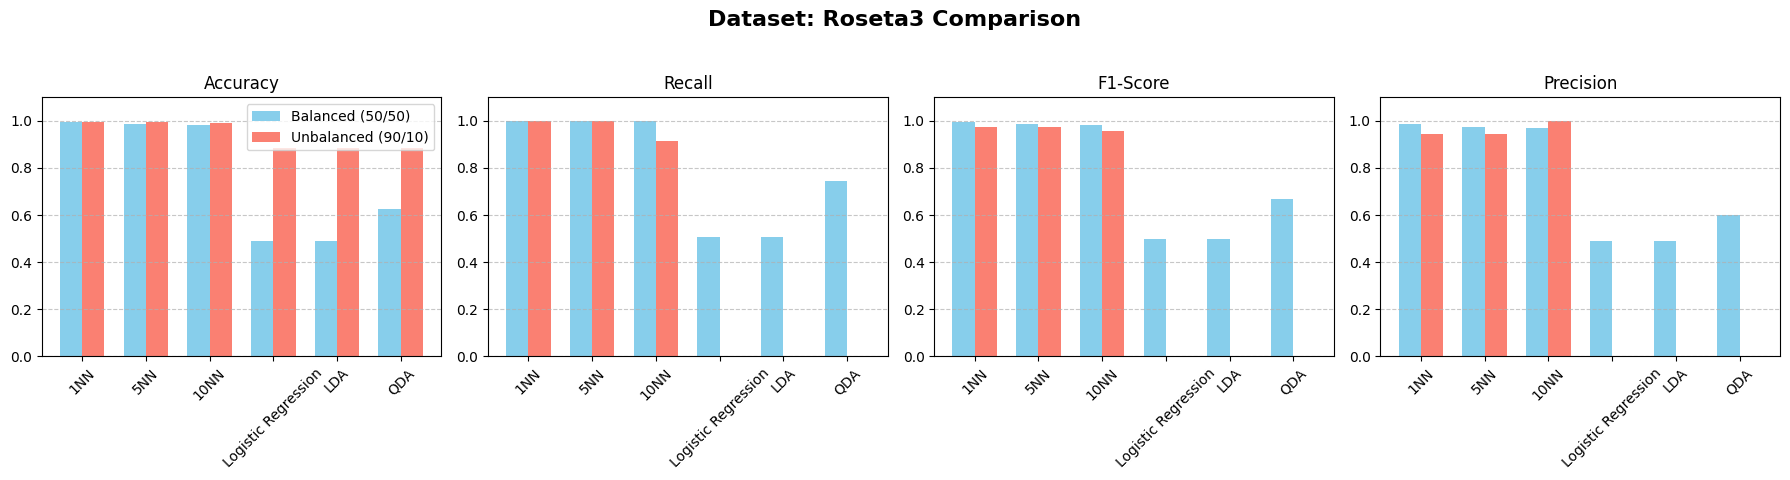

In [35]:
import pandas as pd

dataset_names = ["Headlights", "Shell", "DD", "XOR", "Chess4", "Roseta2", "Roseta3"]
metrics = ['Accuracy', 'Recall', 'F1-Score','Precision']

for i in range(len(dataset_names)):
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    fig.suptitle(f"Dataset: {dataset_names[i]} Comparison", fontsize=16, fontweight='bold')

    data_bal = {
        'Model': list(models.keys()),
        'Accuracy': [accuracy_balanced[m][i] for m in models],
        'Recall': [recall_balanced[m][i] for m in models],
        'F1-Score': [f1_balanced[m][i] for m in models],
        'Precision': [precision_balanced[m][i] for m in models]
    }
    
    data_unbal = {
        'Model': list(models.keys()),
        'Accuracy': [accuracy_unbalanced[m][i] for m in models],
        'Recall': [recall_unbalanced[m][i] for m in models],
        'F1-Score': [f1_unbalanced[m][i] for m in models],
        'Precision': [precision_unbalanced[m][i] for m in models]
    }

    df_bal = pd.DataFrame(data_bal)
    df_unbal = pd.DataFrame(data_unbal)
    
    for j, metric in enumerate(['Accuracy', 'Recall', 'F1-Score', 'Precision']):
        x = np.arange(len(models))
        width = 0.35

        axes[j].bar(x - width/2, df_bal[metric], width, label='Balanced (50/50)', color='skyblue')
        axes[j].bar(x + width/2, df_unbal[metric], width, label='Unbalanced (90/10)', color='salmon')

        axes[j].set_title(f'{metric}')
        axes[j].set_xticks(x)
        axes[j].set_xticklabels(df_bal['Model'], rotation=45)
        axes[j].set_ylim(0, 1.1)
        axes[j].grid(axis='y', linestyle='--', alpha=0.7)
        if j == 0: axes[j].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

boundary decision